# Pandas Basics

## What is Pandas?

* Name derived from "panel data" or "python data analysis"
* Data exploration and analysis tool
* 2 main data structures:
  * `Series` - A 1-dimensional data structure (i.e. a column)
  * `DataFrame` - A 2-dimensional data structure (i.e. a table)

## Why Pandas?

* Speed: Number crunching is done by the Numpy library which performs arithmetic using native C code
* Power: SQL-like capabilities together with Python
* Visualizations: Integrate with libraries such as: Matplotlib, Bokeh, seaborn

## The standard Numpy and Pandas imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load the data

Data is from the Origins Game Fair
* main site - https://www.originsgamefair.com/
* schedule - https://tabletop.events/conventions/origins-game-fair-2026/schedule
* scheule CSV - https://s3.amazonaws.com/conventionshare.tabletop.events/schedules/origins-game-fair-2026-schedule.csv

In [2]:
# read_csv has numerous options that let you dial in how 
# the data is loaded i.e. loading only certain columns, 
# specifying data types, specifying date/time format
df = pd.read_csv('origins-game-fair-2026-schedule.csv')

In [3]:
# Pandas can import data from a number of different formats
", ".join([s for s in dir(pd) if s.startswith('read_')])

'read_clipboard, read_csv, read_excel, read_feather, read_fwf, read_hdf, read_html, read_iceberg, read_json, read_orc, read_parquet, read_pickle, read_sas, read_spss, read_sql, read_sql_query, read_sql_table, read_stata, read_table, read_xml'

## Examine the Dataframe

### List Columns

In [4]:
df.columns

Index(['Event Name', 'Event Number', 'Event Type', 'Host Names', 'Description',
       'Price', 'Age Range', 'Max Tickets', 'Sold Count', 'Wait Count',
       'Starts', 'Start Date (UTC)', 'Duration (minutes)', 'More Info', 'Room',
       'Space', 'Date Created', 'Date Updated', 'View URI',
       'Conference Sessions', 'Trade Day Sessions', 'Game Master (GM)',
       'Game Edition', 'Game Publisher', 'Game Complexity',
       'Player Experience', 'Rules Taught', 'Is your event a tournament?',
       'What style of tournament', 'Tournament Stage/Round', 'Sub-Category',
       'Hosting Company, Group, or Club', 'Game System',
       'Will characters be provided?'],
      dtype='str')

### Column Data Types

In [5]:
df.dtypes[:5]  # Data types of first 5 columns

Event Name        str
Event Number    int64
Event Type        str
Host Names        str
Description       str
dtype: object

### df.info() - Column, Non-Null Count, and Datatypes

The output from `df.info()` is lengthy here is an excerpt.

```
<class 'pandas.DataFrame'>
RangeIndex: 8668 entries, 0 to 8667
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   Event Name                       8668 non-null   str  
 1   Event Number                     8668 non-null   int64
 ...
 31  Hosting Company, Group, or Club  7804 non-null   str  
 32  Game System                      2953 non-null   str  
 33  Will characters be provided?     2463 non-null   str  
dtypes: int64(8), str(26)
memory usage: 2.2 MB
```

### Row Count

In [6]:
len(df)  # how many rows

8668

### Index

In [7]:
df.index

RangeIndex(start=0, stop=8668, step=1)

## Examine the Data

### Inspect values within field

In [8]:
df['Event Type'].value_counts()[:5]

Event Type
Board Game          3321
Roleplaying Game    2447
Miniatures Game      795
Card Game            594
Escape Games         343
Name: count, dtype: int64

### A simple pie chart

<Axes: >

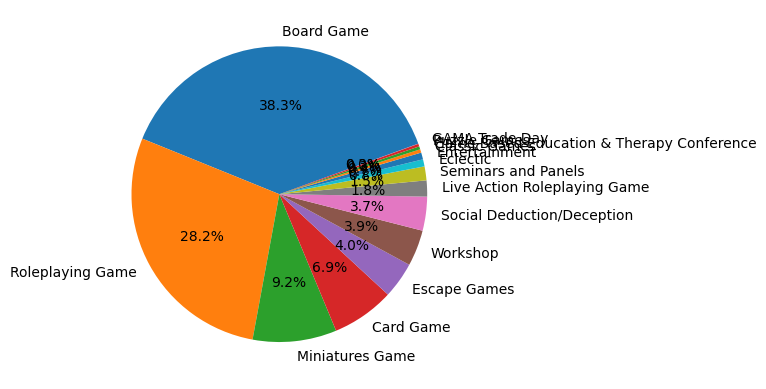

In [9]:
# A quick and dirty pie chart (uses the Matplot lib library)
df['Event Type'].value_counts().plot.pie(
    autopct='%1.1f%%', startangle=20
)

### Get stats for some numeric fields

In [12]:
df[['Price', 'Max Tickets', 'Duration (minutes)']].describe()

,Price,Max Tickets,Duration (minutes)
count,8668.000000,8668.000000,8668.000000
mean,4.693470,14.121251,137.619982
std,11.381906,37.216541,79.974612
min,0.000000,0.000000,30.000000
25%,0.000000,5.000000,60.000000
50%,0.000000,6.000000,120.000000
75%,0.000000,10.000000,180.000000
max,243.000000,750.000000,600.000000


### Price histogram

In [13]:
def show_histogram(my_df, my_column, interval=10, title=None):
    my_series = my_df[my_column]
    my_stats = my_series.describe()
    my_min = int(my_stats['min'])
    my_max = int(my_stats['max'])
    my_series.hist(bins=(my_max - my_min) // interval)
    plt.title(
        title or f'Distribution of {my_column}s'
    )
    plt.xlabel(my_column)
    plt.ylabel('Frequency')
    plt.show()    

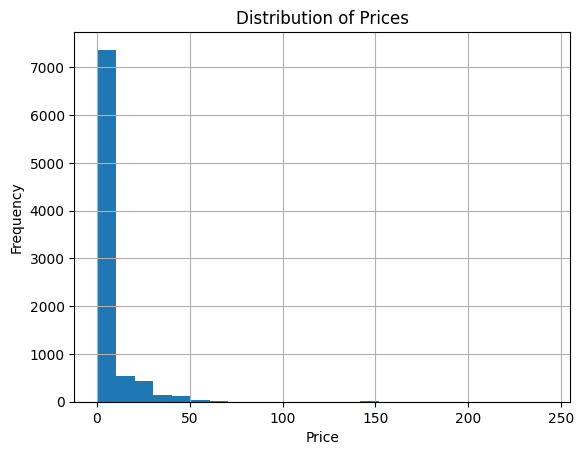

In [14]:
show_histogram(df, 'Price')

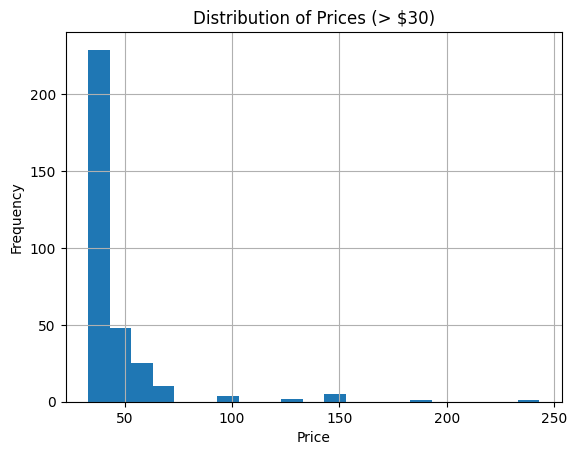

In [15]:
show_histogram(
    df[df['Price'] > 30],
    'Price',
    title="Distribution of Prices (> $30)"
)

## Dealing with Dates

We have 1 column containing a UTC datetime which was read as a string

In [16]:
START_DATE_UTC_FIELD = 'Start Date (UTC)'
df[START_DATE_UTC_FIELD].head(3)

0    2026-06-17T12:00:00
1    2026-06-17T12:00:00
2    2026-06-17T14:00:00
Name: Start Date (UTC), dtype: str

### Convert string to datetime place result in new column

In [17]:
# without the utc=True argument the datetime will be naive (lacking timezone)
df['start_date_utc'] = pd.to_datetime(df[START_DATE_UTC_FIELD], utc=True)
df['start_date_utc'].head(3)

0   2026-06-17 12:00:00+00:00
1   2026-06-17 12:00:00+00:00
2   2026-06-17 14:00:00+00:00
Name: start_date_utc, dtype: datetime64[us, UTC]

### Convert to local time

In [18]:
df['start_date'] = df['start_date_utc'].dt.tz_convert('America/New_York')
df['start_date'].head(3)

0   2026-06-17 08:00:00-04:00
1   2026-06-17 08:00:00-04:00
2   2026-06-17 10:00:00-04:00
Name: start_date, dtype: datetime64[us, America/New_York]

### View resulting "start date" columns.

In [19]:
df[[START_DATE_UTC_FIELD, 'start_date_utc', 'start_date']].head(5)

,Start Date (UTC),start_date_utc,start_date
0,2026-06-17T12:00:00,2026-06-17 12:00:00+00:00,2026-06-17 08:00:00-04:00
1,2026-06-17T12:00:00,2026-06-17 12:00:00+00:00,2026-06-17 08:00:00-04:00
2,2026-06-17T14:00:00,2026-06-17 14:00:00+00:00,2026-06-17 10:00:00-04:00
3,2026-06-17T14:00:00,2026-06-17 14:00:00+00:00,2026-06-17 10:00:00-04:00
4,2026-06-17T15:00:00,2026-06-17 15:00:00+00:00,2026-06-17 11:00:00-04:00


### .info for the "start date" columns

In [20]:
df[[START_DATE_UTC_FIELD, 'start_date_utc', 'start_date']].info()

<class 'pandas.DataFrame'>
RangeIndex: 8668 entries, 0 to 8667
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype                           
---  ------            --------------  -----                           
 0   Start Date (UTC)  8668 non-null   str                             
 1   start_date_utc    8668 non-null   datetime64[us, UTC]             
 2   start_date        8668 non-null   datetime64[us, America/New_York]
dtypes: datetime64[us, America/New_York](1), datetime64[us, UTC](1), str(1)
memory usage: 203.3 KB


### String -> datetime when reading csv

In [21]:
parsed_date_df = pd.read_csv(
    'origins-game-fair-2026-schedule.csv',
    usecols=[START_DATE_UTC_FIELD],
    parse_dates=[START_DATE_UTC_FIELD],
    date_format='%Y-%m-%dT%H:%M:%S',
)
parsed_date_df[START_DATE_UTC_FIELD].head(3)

0   2026-06-17 12:00:00
1   2026-06-17 12:00:00
2   2026-06-17 14:00:00
Name: Start Date (UTC), dtype: datetime64[us]

### Naive datetime to timezone aware

In [22]:
parsed_date_df['start_date_utc'] = parsed_date_df[START_DATE_UTC_FIELD].dt.tz_localize('UTC')
parsed_date_df['start_date_utc'].head(3)

0   2026-06-17 12:00:00+00:00
1   2026-06-17 12:00:00+00:00
2   2026-06-17 14:00:00+00:00
Name: start_date_utc, dtype: datetime64[us, UTC]

## Filtering

### Filter by Datetime

In [23]:
from datetime import datetime
from zoneinfo import ZoneInfo

nyc_timezone = ZoneInfo('America/New_York')
filter_start_date = datetime(2026, 6, 19, tzinfo=nyc_timezone)

# Events on Sunday the 22nd
filtered_df = df[df['start_date'] >= filter_start_date]
print(f"{len(filtered_df)=}")
filtered_df[['Event Name', 'start_date']].head(3)

len(filtered_df)=5496


,Event Name,start_date
3172,Are You a Werewolf / Ultimate Werewolf,2026-06-19 00:00:00-04:00
3173,Blood on the Clocktower: Trouble Brewing,2026-06-19 00:00:00-04:00
3174,For The Night Is Dark and Full of Terrors,2026-06-19 00:00:00-04:00


### Filter by Datetime Range and Other Criteria

In [24]:
from datetime import timedelta
filter_end_date = filter_start_date + timedelta(days=1)
date_mask = df['start_date'].between(
    filter_start_date,
    filter_end_date
)

filtered_df = df[date_mask]
print(f"{len(filtered_df)=}")
filtered_df[['Event Name', 'start_date']].head(3)

len(filtered_df)=2451


,Event Name,start_date
3172,Are You a Werewolf / Ultimate Werewolf,2026-06-19 00:00:00-04:00
3173,Blood on the Clocktower: Trouble Brewing,2026-06-19 00:00:00-04:00
3174,For The Night Is Dark and Full of Terrors,2026-06-19 00:00:00-04:00


### Filtering by multiple criteria

Use the `&` (bitwise AND), `|` (bitwise OR), and `!` NOT to build complex filters

In [25]:
filtered_df = df[
    date_mask &
    (df['Event Type'] == 'Roleplaying Game')
]
print(f"{len(filtered_df)=}")
filtered_df[['Event Name', 'Event Type', 'start_date']].sample(n=3)

len(filtered_df)=652


,Event Name,Event Type,start_date
5389,House of Lost Dolls,Roleplaying Game,2026-06-19 19:00:00-04:00
5323,EGO Assignment A2-1 Redemption Songs,Roleplaying Game,2026-06-19 19:00:00-04:00
3446,They Came From Beyond Space,Roleplaying Game,2026-06-19 09:00:00-04:00


### Filtering for missing values

In [26]:
filtered_df = df[df['Game System'].isna()]
filtered_df[['Event Name', 'Event Type', 'Game System']].sample(5)

,Event Name,Event Type,Game System
3969,Grendel: The Game of Crime and Mayhem,Board Game,NaN
7616,23 Knives,Board Game,NaN
196,Build A Large Foam Weapon,Workshop,NaN
407,Blood on the Clocktower: Catfishing,Social Deduction/Deception,NaN
4180,PocketParks: Learn to play,Card Game,NaN


### Filtering for values that AREN'T missing

In [27]:
filtered_df = df[df['Game System'].notna()]
filtered_df[['Event Name', 'Event Type', 'Game System']].sample(5)

,Event Name,Event Type,Game System
5655,"Sparks #303B ""When Raddich Calls""",Roleplaying Game,"Star Wars RPG, 2nd ed Revised"
2970,RBS #006 - Battle of the Brands,Roleplaying Game,Pathfinder
7577,Amtgard 101,Live Action Roleplaying Game,Amtgard v8
7146,Golden Hour: ADGNEPSEF555,Roleplaying Game,Golden Hour
5773,Non FWS: The Characters They Won’t Let Me Play,Roleplaying Game,Dungeons and Dragons


## Practical Example - Compare popularity of Event Types between the 2 years

### Function to load csv files

In [28]:
def load_csv(filename: str) -> pd.DataFrame:
    return pd.read_csv(
        filename,
        usecols=['Event Type', 'Max Tickets', 'Sold Count', 'Wait Count'],
    )

### Load 2025 data

In [29]:
origins2025_df = load_csv('origins-game-fair-2025-schedule.csv')
origins2025_df.head(3)

,Event Type,Max Tickets,Sold Count,Wait Count
0,Seminars and Panels,250,152,0
1,Board Game,5,5,2
2,Live Action Roleplaying Game,4,0,0


### Load 2026 data

In [30]:
origins2026_df = load_csv('origins-game-fair-2026-schedule.csv')
origins2026_df.head(3)

,Event Type,Max Tickets,Sold Count,Wait Count
0,GAMA Trade Day,150,85,0
1,GAMA Trade Day,50,24,0
2,Board Game,6,6,0


### Function to compute sold ratio

In [39]:
def get_sold_ratio(my_df: pd.DataFrame) -> pd.DataFrame:
    my_df = my_df[my_df['Max Tickets'] > 0]
    my_df['sold_ratio'] = (my_df['Sold Count'] + my_df['Wait Count']) / my_df['Max Tickets']
    return my_df

### DataFrame with sold_ratio

In [32]:
origins2025_df = get_sold_ratio(origins2025_df)
origins2026_df = get_sold_ratio(origins2026_df)
origins2026_df.sample(5)

,Event Type,Max Tickets,Sold Count,Wait Count,sold_ratio
5328,Social Deduction/Deception,12,6,0,0.500000
8247,Board Game,6,5,0,0.833333
8592,Board Game,2,2,1,1.500000
2253,Miniatures Game,12,0,0,0.000000
7920,Social Deduction/Deception,12,7,0,0.583333


### Function to compute average (mean) sold_ratio by EventType

In [40]:
def get_sold_ratio_by_event_type(my_df: pd.DataFrame) -> pd.Series:
    return my_df.groupby(by='Event Type')['sold_ratio'].mean()

### Series of average sold_ratio by Event Type

In [42]:
sold_ratio_by_event_type_2025 = get_sold_ratio_by_event_type(origins2025_df)
sold_ratio_by_event_type_2026 = get_sold_ratio_by_event_type(origins2026_df)
sold_ratio_by_event_type_2026.sample(5)

Event Type
GAMA Trade Day                  0.523333
Live Action Roleplaying Game    0.191365
Classic Games                   1.210938
Social Deduction/Deception      0.519066
Escape Games                    0.099211
Name: sold_ratio, dtype: float64

### Create a DataFrame from the two series

In [35]:
plot_df = pd.DataFrame({
    '2025': sold_ratio_by_event_type_2025,
    '2026': sold_ratio_by_event_type_2026,
})
plot_df.sample(5)

,2025,2026
Event Type,,
Game-Based Education & Therapy Conference,NaN,0.559103
Miniatures Game,0.753545,0.647489
Puzzle Games,0.370117,1.137375
Classic Games,0.450347,1.210938
Eclectic,0.868011,0.751116


### Plot It!

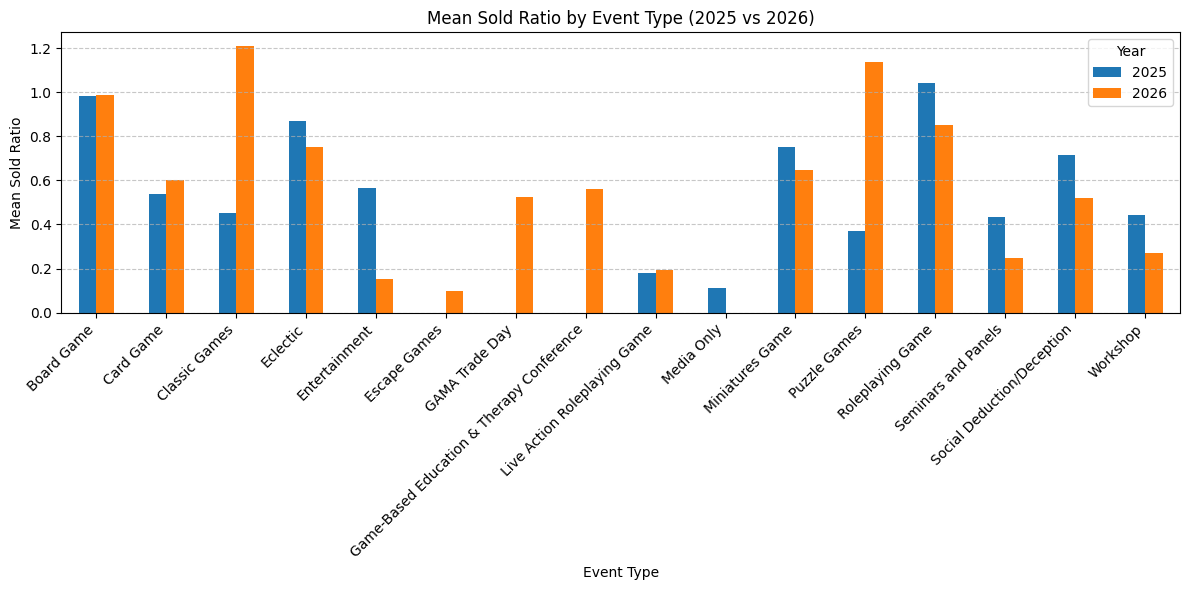

In [37]:
plot_df.plot.bar(figsize=(12, 6))

plt.title('Mean Sold Ratio by Event Type (2025 vs 2026)')
plt.ylabel('Mean Sold Ratio')
plt.xlabel('Event Type')
plt.xticks(rotation=45, ha='right') # Rotates labels for readability
plt.legend(title='Year')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Resources

* https://jupyter.org/
* https://pandas.pydata.org/
* https://pandas.pydata.org/pandas-docs/stable/user_guide/10min.html
* https://matplotlib.org/
* https://github.com/jocassid/Talk-PandasBasics (GitHub repo for this presentation)